# 1 — Setup
Breve configuração do ambiente e instalação de dependências.

In [76]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'
])

0

# 2 — Imports e Configurações
Importações principais e configurações (warnings, matplotlib, etc.).

In [51]:
import wfdb
import pandas as pd

ann = wfdb.rdann('data/22', 'atr')

df = pd.DataFrame({
    'sample': ann.sample,
    'time': [f"{int(x//3600):02d}:{int((x%3600)//60):02d}:{x%60:05.2f}" for x in ann.sample / 128],
    'symbol': ann.symbol,
    'aux_note': ann.aux_note,
})

df['rhythm'] = df['aux_note'].replace('', None).ffill()

df

,sample,time,symbol,aux_note,rhythm
0,157319,00:20:29.05,+,(N,(N
1,157339,00:20:29.21,N,,(N
2,157427,00:20:29.90,N,,(N
3,157482,00:20:30.33,A,,(N
4,157591,00:20:31.18,N,,(N
...,...,...,...,...,...
128202,11143957,24:11:02.16,N,,(N
128203,11144010,24:11:02.58,V,,(N
128204,11144098,24:11:03.27,N,,(N
128205,11144181,24:11:03.91,N,,(N


# 3 — Carregamento de Dados e Anotações
Leitura do registro WFDB e criação do `DataFrame` com anotações.

In [52]:
print('Symbol column statistics:')
display(df['symbol'].describe())
print('\nUnique symbol values:')
display(df['symbol'].unique())

Symbol column statistics:


count     128207
unique         5
top            N
freq       95430
Name: symbol, dtype: object


Unique symbol values:


<StringArray>
['+', 'N', 'A', 'V', '"']
Length: 5, dtype: str

In [53]:
print('Aux_note column statistics:')
display(df['aux_note'].describe())
print('\nUnique aux_note values:')
display(df['aux_note'].unique())

Aux_note column statistics:


count     128207
unique        11
top             
freq      124758
Name: aux_note, dtype: object


Unique aux_note values:


<StringArray>
['(N', '', '(B', '(AB', '(VT', '(T', '(SVTA', 'MISSB', '(AFIB', '(SBR',
 ' Aux']
Length: 11, dtype: str

In [54]:
print('Rhythm column statistics:')
display(df['rhythm'].describe())
print('\nUnique rhythm values:')
display(df['rhythm'].unique())

Rhythm column statistics:


count     128207
unique        10
top           (N
freq      106501
Name: rhythm, dtype: object


Unique rhythm values:


<StringArray>
['(N', '(B', '(AB', '(VT', '(T', '(SVTA', 'MISSB', '(AFIB', '(SBR', ' Aux']
Length: 10, dtype: str

In [55]:
# Combinações possíveis de symbol e rhythm
df.groupby(['symbol', 'rhythm']).size().reset_index(name='count')

,symbol,rhythm,count
0,"""", Aux,1
1,"""",MISSB,16
2,+,(AB,188
3,+,(AFIB,102
4,+,(B,996
5,+,(N,1636
6,+,(SBR,107
7,+,(SVTA,36
8,+,(T,282
9,+,(VT,85


# 4 — Símbolos e Ritmos (Dicionário)
Tabela com significado dos símbolos e ritmos presentes nas anotações.

**Símbolos (`symbol`):**

| Símbolo | Significado |
|---|---|
| `N` | Batimento normal |
| `A` | Batimento atrial ectópico |
| `V` | Batimento ventricular ectópico |
| `+` | Mudança de ritmo (ver `aux_note`) |
| `"` | Comentário do anotador |

**Ritmos (`aux_note`):**

| aux_note | Significado |
|---|---|
| `(N` | Ritmo sinusal normal |
| `(AFIB` | Fibrilação atrial |
| `(B` | Bigeminismo ventricular |
| `(AB` | Bigeminismo atrial |
| `(VT` | Taquicardia ventricular |
| `(SVTA` | Taquicardia supraventricular |
| `(SBR` | Bradicardia sinusal |
| `(T` | Taquicardia sinusal |
| `MISSB` | Batimento perdido (não detectado) |
| ` Aux` | Anotação auxiliar genérica |

# 5 — Visualizações
Gráficos de combinações de símbolos/ritmos e transições entre ritmos.

**Ritmo — Como identificar**

| Ritmo | Como identificar |
|---|---|
| `N` | Batimentos regulares, espaçados uniformemente (sinusal normal) |
| `AFIB` | Intervalos totalmente irregulares, sem padrão — fibrilação atrial |
| `B` | Alternância N–V–N–V (bigeminismo ventricular) |
| `AB` | Alternância N–A–N–A (bigeminismo atrial) |
| `T` | Batimentos regulares com frequência alta (taquicardia) |
| `SBR` | Batimentos regulares com frequência baixa (bradicardia sinusal) |
| `VT` | Sequência de `V` consecutivos e rápidos (taquicardia ventricular) |
| `SVTA` | Sequência de `A` consecutivos e rápidos (taquicardia supraventricular) |

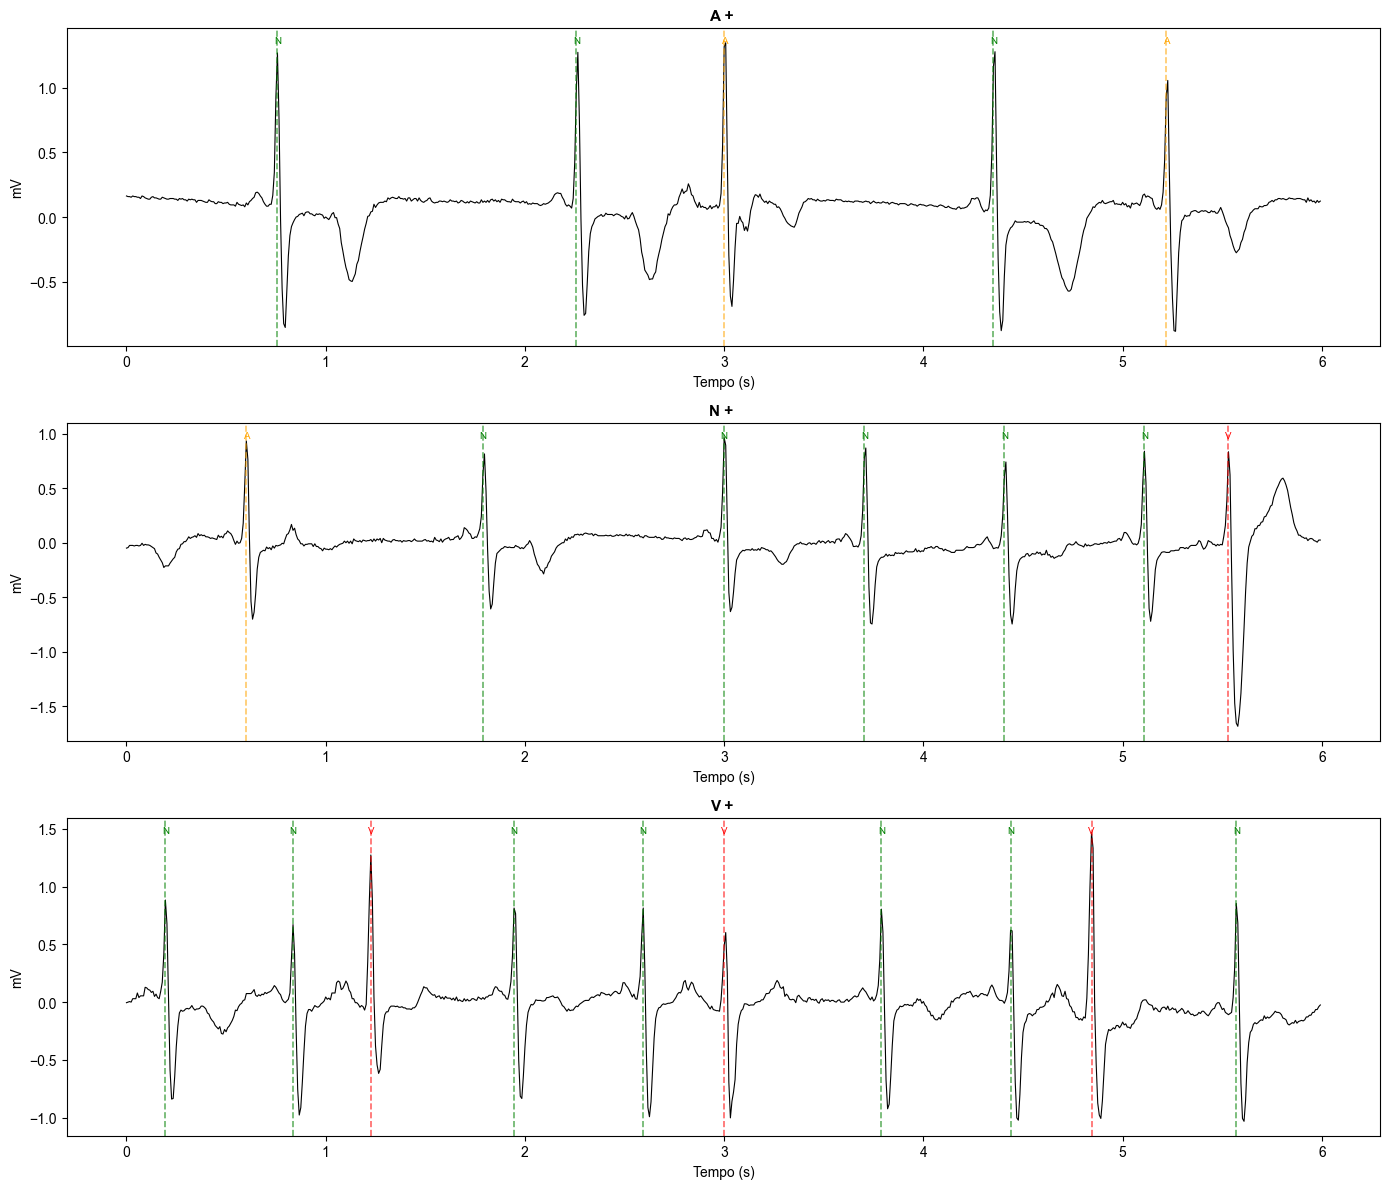

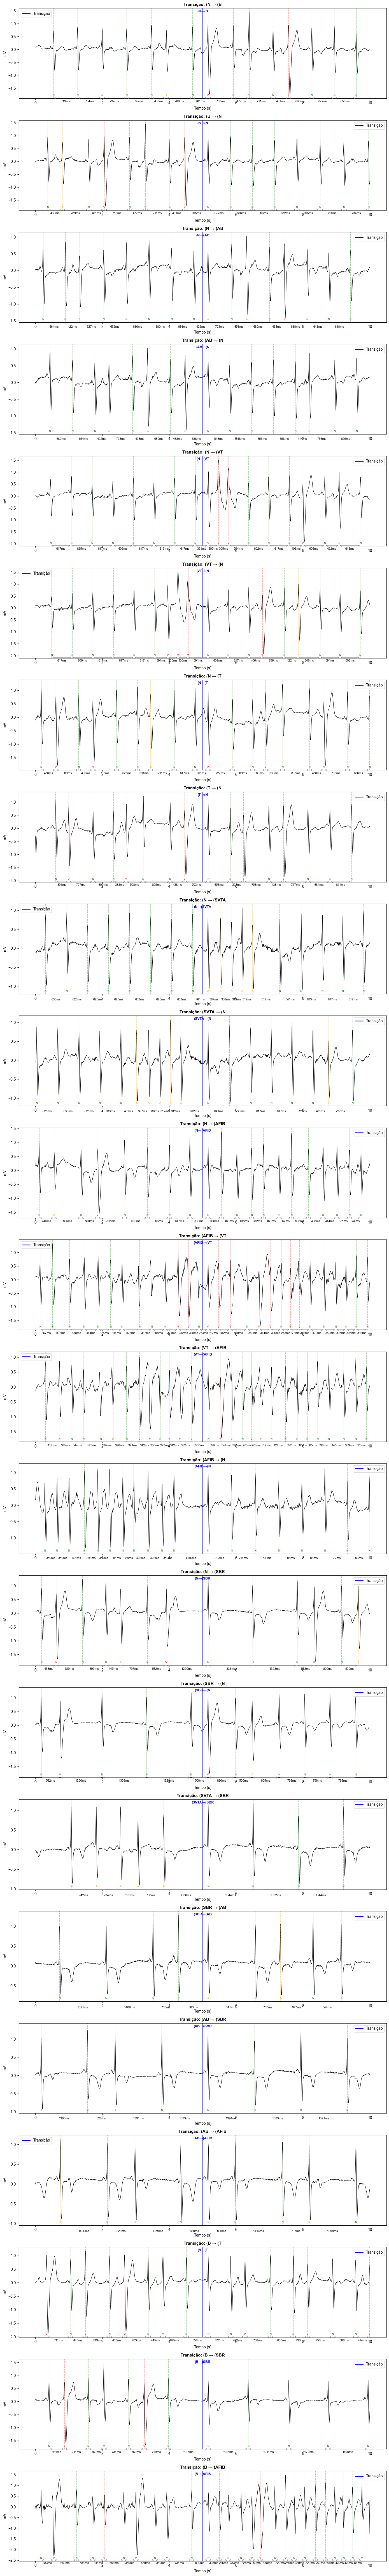

In [62]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

ann = wfdb.rdann('data/22', 'atr')
df = pd.DataFrame({
    'sample': ann.sample,
    'symbol': ann.symbol,
    'aux_note': ann.aux_note,
    'rhythm': pd.Series(np.where(ann.aux_note == '', None, ann.aux_note)).ffill()
})

record = wfdb.rdrecord('data/22')
signal = record.p_signal[:, 0]
fs = 128

cor_simbolo = {'N': 'green', 'A': 'orange', 'V': 'red', '"': 'gray', '+': 'black'}
ritmos_com_rr = {'(N', '(AFIB', '(B', '(AB', '(T', '(SBR', '(VT', '(SVTA'}

# --- PARTE 1: combinações individuais ---
combos = [c for c in df.groupby(['symbol', 'rhythm']).size().index if c[0] not in ('+', '"')]
janela = 6 * fs

fig, axes = plt.subplots(len(combos), 1, figsize=(14, 4 * len(combos)))

for ax, (sym, rhy) in zip(axes, combos):
    rows = df[(df['symbol'] == sym) & (df['rhythm'] == rhy)]
    beat_sample = int(rows.iloc[len(rows) // 2]['sample'])
    start = max(0, beat_sample - janela // 2)
    end   = min(len(signal), start + janela)

    t = np.arange(end - start) / fs
    ax.plot(t, signal[start:end], color='black', linewidth=0.8)

    beats_in_window = df[(df['sample'] >= start) & (df['sample'] < end) & ~df['symbol'].isin(['+', '"'])]
    ymax = signal[start:end].max()
    ymin = signal[start:end].min()

    prev_x = None
    for _, row in beats_in_window.iterrows():
        x = (row['sample'] - start) / fs
        c = cor_simbolo.get(row['symbol'], 'blue')
        ax.axvline(x, color=c, alpha=0.6, linewidth=1.2, linestyle='--')
        ax.text(x, ymax, row['symbol'], fontsize=7, color=c, ha='center')

        if rhy in ritmos_com_rr and prev_x is not None:
            rr_ms = (x - prev_x) * 1000
            mid_x = (x + prev_x) / 2
            ax.annotate('', xy=(x, ymin), xytext=(prev_x, ymin),
                        arrowprops=dict(arrowstyle='<->', color='gray', lw=0.8))
            ax.text(mid_x, ymin - 0.05, f'{rr_ms:.0f}ms', fontsize=6,
                    ha='center', va='top', color='gray')
        prev_x = x

    ax.set_title(f"{sym} + {rhy}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('mV')

plt.tight_layout()
plt.show()


# --- PARTE 2: transições entre ritmos ---
transicoes = df[df['symbol'] == '+'].reset_index(drop=True)
pares = []
for i in range(len(transicoes) - 1):
    r1 = transicoes.loc[i, 'rhythm']
    r2 = transicoes.loc[i+1, 'rhythm']
    if r1 != r2:
        pares.append((r1, r2, int(transicoes.loc[i+1, 'sample'])))

vistos = set()
pares_unicos = []
for r1, r2, s in pares:
    if (r1, r2) not in vistos:
        vistos.add((r1, r2))
        pares_unicos.append((r1, r2, s))

janela_trans = 5 * fs
fig2, axes2 = plt.subplots(len(pares_unicos), 1, figsize=(14, 4 * len(pares_unicos)))
if len(pares_unicos) == 1:
    axes2 = [axes2]

for ax, (r1, r2, trans_sample) in zip(axes2, pares_unicos):
    start = max(0, trans_sample - janela_trans)
    end   = min(len(signal), trans_sample + janela_trans)

    t = np.arange(end - start) / fs
    ax.plot(t, signal[start:end], color='black', linewidth=0.8)

    x_trans = (trans_sample - start) / fs
    ax.axvline(x_trans, color='blue', linewidth=2, linestyle='-', label='Transição')
    ax.text(x_trans, signal[start:end].max(), f'{r1}→{r2}', fontsize=9,
            color='blue', ha='center', fontweight='bold')

    beats_in_window = df[(df['sample'] >= start) & (df['sample'] < end) & ~df['symbol'].isin(['+', '"'])]
    ymin = signal[start:end].min()
    ymax = signal[start:end].max()

    prev_x = None
    for _, row in beats_in_window.iterrows():
        x = (row['sample'] - start) / fs
        c = cor_simbolo.get(row['symbol'], 'gray')
        ax.axvline(x, color=c, alpha=0.4, linewidth=0.8, linestyle='--')
        ax.text(x, ymin, row['symbol'], fontsize=7, color=c, ha='center', va='top')

        if prev_x is not None:
            rr_ms = (x - prev_x) * 1000
            mid_x = (x + prev_x) / 2
            ax.annotate('', xy=(x, ymin - 0.15), xytext=(prev_x, ymin - 0.15),
                        arrowprops=dict(arrowstyle='<->', color='gray', lw=0.8))
            ax.text(mid_x, ymin - 0.22, f'{rr_ms:.0f}ms', fontsize=8,
                    ha='center', va='top', color='black')
        prev_x = x

    ax.set_title(f'Transição: {r1} → {r2}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tempo (s)')
    ax.set_ylabel('mV')
    ax.legend()

plt.tight_layout()
plt.show()

# 6 — Morfologia dos Batimentos
Análises e médias de trechos em torno dos picos (morfologia).

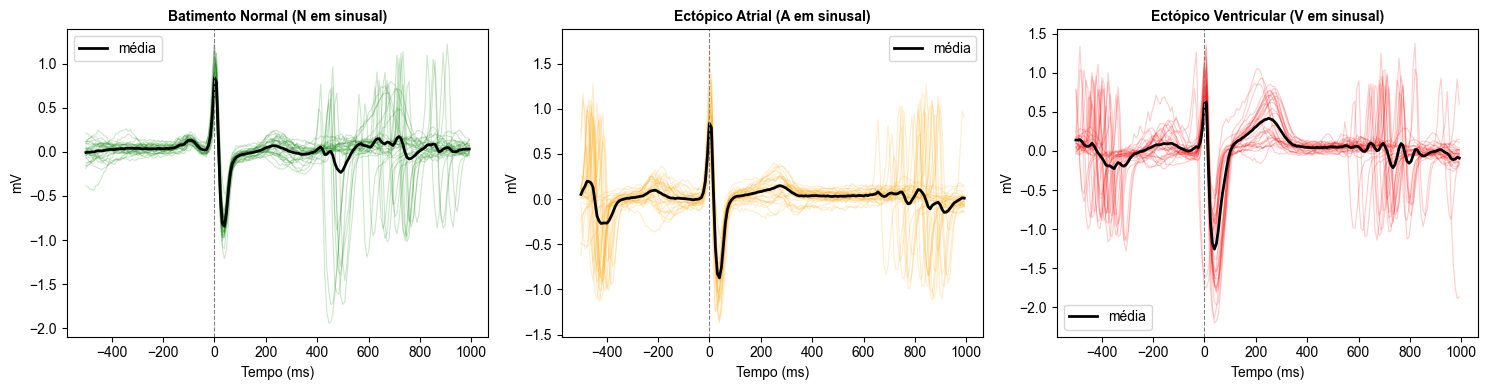

In [57]:
import numpy as np

pre  = int(0.5 * fs)   # 500ms antes
post = int(1.0 * fs)   # 1000ms depois
t = np.arange(-pre, post) / fs * 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ('N', '(N',  'green',  'Batimento Normal (N em sinusal)'),
    ('A', '(N',  'orange', 'Ectópico Atrial (A em sinusal)'),
    ('V', '(N',  'red',    'Ectópico Ventricular (V em sinusal)'),
]

for ax, (sym, rhy, cor, titulo) in zip(axes, configs):
    rows = df[(df['symbol'] == sym) & (df['rhythm'] == rhy)].sample(min(30, len(df[(df['symbol'] == sym) & (df['rhythm'] == rhy)])), random_state=42)
    trechos = []
    for _, row in rows.iterrows():
        s = int(row['sample'])
        if s - pre < 0 or s + post >= len(signal):
            continue
        trecho = signal[s - pre:s + post]
        ax.plot(t, trecho, color=cor, alpha=0.2, linewidth=0.8)
        trechos.append(trecho)

    if trechos:
        ax.plot(t, np.mean(trechos, axis=0), color='black', linewidth=2, label='média')

    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Tempo (ms)')
    ax.set_ylabel('mV')
    ax.legend()

plt.tight_layout()
plt.show()

# 7 — Pré-processamento e Extração de Trechos
Extração de janelas ao redor dos picos, normalização e balanceamento.

In [63]:
pre  = int(0.3 * fs)   # 300ms antes do pico
post = int(0.5 * fs)   # 500ms depois
X, y = [], []

for _, row in df[df['symbol'].isin(['N', 'A', 'V'])].iterrows():
    s = int(row['sample'])
    if s - pre < 0 or s + post >= len(signal):
        continue
    X.append(signal[s - pre:s + post])
    y.append(row['symbol'])

X = np.array(X)  # shape: (n_batimentos, n_amostras)

# 8 — Definição do Modelo
Arquitetura do modelo e compilação.

In [65]:
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import LabelEncoder

# filtro passa-banda (remove ruído e baseline wander)
def bandpass(sig, fs, low=0.5, high=40):
    b, a = butter(3, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, sig)

X = np.array([bandpass(x, fs) for x in X])

# normalização por batimento
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# label encoding
le = LabelEncoder()
y_enc = le.fit_transform(y)  # N=1, A=0, V=2 (ordem alfabética)

In [69]:
from imblearn.over_sampling import SMOTE

X_flat = X.reshape(len(X), -1)
X_bal, y_bal = SMOTE(random_state=42).fit_resample(X_flat, y_enc)
X_bal = X_bal.reshape(-1, X.shape[1], 1)

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

In [71]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(X.shape[1], 1)),
    layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')  # N, A, V
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 102, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 102, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 51, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 51, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 51, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,547 (174.01 KB)

 Trainable params: 44,099 (172.26 KB)

 Non-trainable params: 448 (1.75 KB)

# 9 — Treinamento
Treinamento do modelo e callbacks.

In [72]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.8731 - loss: 0.3161 - val_accuracy: 0.9015 - val_loss: 0.2527
Epoch 2/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9016 - loss: 0.2492 - val_accuracy: 0.9137 - val_loss: 0.2227
Epoch 3/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9090 - loss: 0.2279 - val_accuracy: 0.9065 - val_loss: 0.2342
Epoch 4/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9148 - loss: 0.2140 - val_accuracy: 0.9188 - val_loss: 0.2039
Epoch 5/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9180 - loss: 0.2048 - val_accuracy: 0.9208 - val_loss: 0.1896
Epoch 6/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.9208 - loss: 0.1980 - val_accuracy: 0.9299 - val_loss: 0.1722
Epoch 7/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - accuracy: 0.9239 - loss: 0.1902 - val_accuracy: 0.9172 - val_loss: 0.2112
Epoch 8/30
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9263 - loss: 0

# 10 — Resultados e Avaliação
Plots de métricas, matriz de confusão e relatórios de classificação.

1790/1790 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


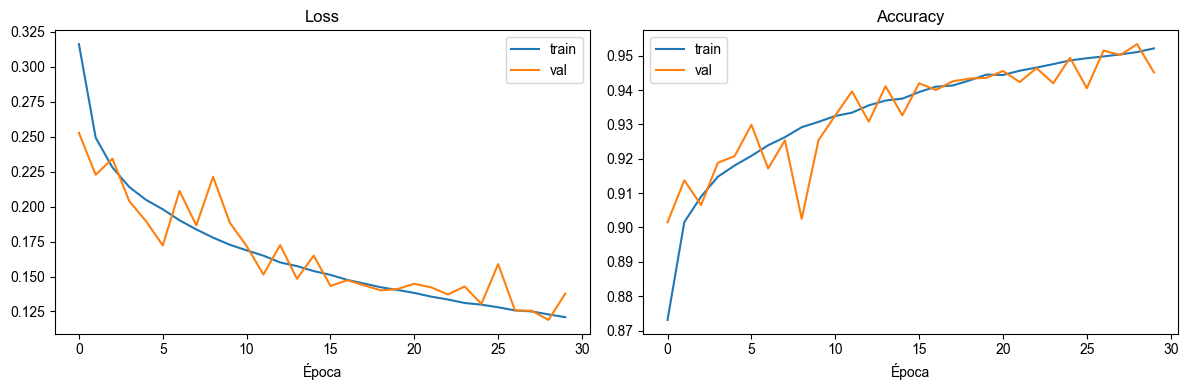

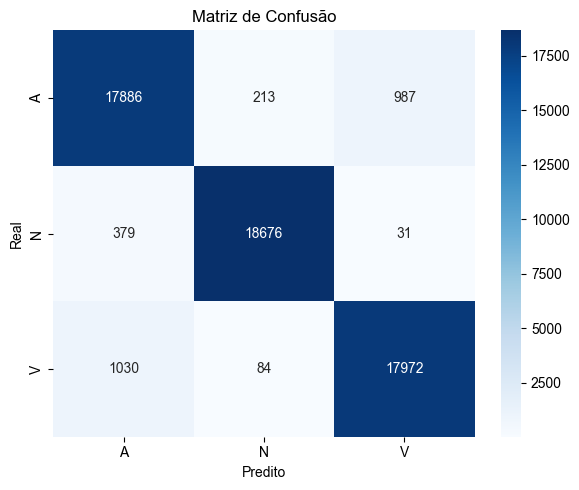

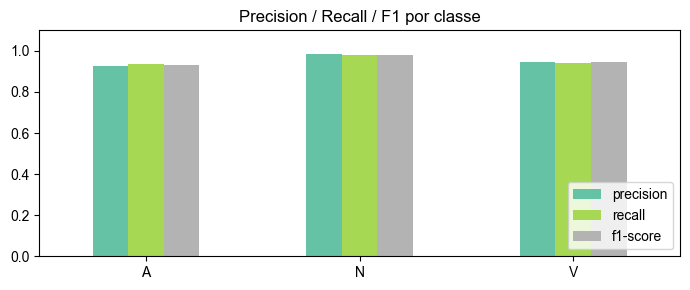

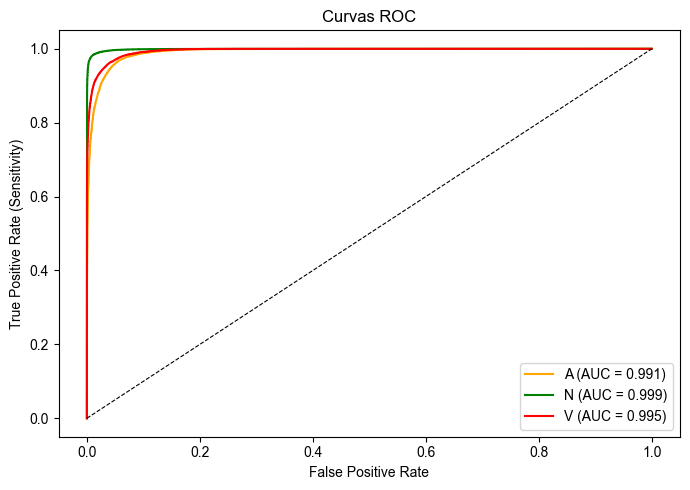

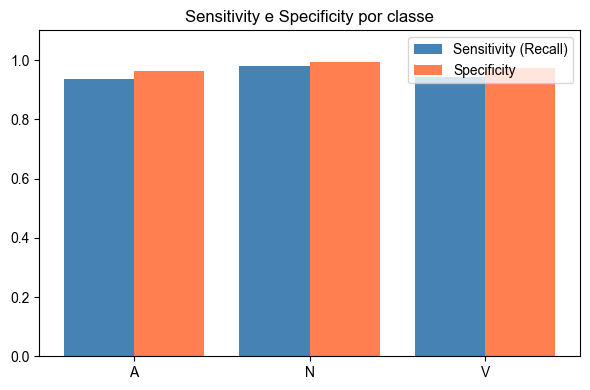

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

y_pred_proba = model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)
classes = le.classes_  # ['A', 'N', 'V']

# --- Loss e Accuracy ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].legend()
plt.tight_layout()
plt.show()

# --- Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão')
plt.tight_layout()
plt.show()

# --- Classification Report ---
report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
report_df = pd.DataFrame(report).T.iloc[:-3][['precision', 'recall', 'f1-score']]

fig, ax = plt.subplots(figsize=(7, 3))
report_df.plot(kind='bar', ax=ax, rot=0, colormap='Set2')
ax.set_title('Precision / Recall / F1 por classe')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# --- Curvas ROC (one-vs-rest) ---
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['orange', 'green', 'red']
for i, (cls, cor) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=cor, label=f'{cls} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Curvas ROC')
ax.legend()
plt.tight_layout()
plt.show()

# --- Sensitivity e Specificity por classe ---
sensitivities, specificities = [], []
for i in range(len(classes)):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp
    sensitivities.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(classes))
ax.bar(x - 0.2, sensitivities, width=0.4, label='Sensitivity (Recall)', color='steelblue')
ax.bar(x + 0.2, specificities, width=0.4, label='Specificity', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 1.1)
ax.set_title('Sensitivity e Specificity por classe')
ax.legend()
plt.tight_layout()
plt.show()